In [2]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install corner

Note: you may need to restart the kernel to use updated packages.


In [163]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import r2_score, mean_absolute_error
import emcee
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cude" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [164]:
#Testdatan, echte Punkte aus deer Dissertation
real_points = [
    # Point V[f]  f[kHz] T[C°]  K        n      Lifetime
    ("I",   350,   10,   250,   426,   0.0275,   1200), #(Keine direkte Probe, konservative Schätzung aus ähnlichen Bedingungen (350 V / 10 kHz / 250 °C), passt zu No. 20, 36, 37)
    ('II',  350,   4,   220,  592,   0.0441,  2610),
    ('III', 400,   4,   250,  475,   0.0104,   740), #Annäherung an No. 34 (400 V / 10 kHz / 250 °C → 741 h), fast identisch
    ('IV',  400,  10,   220,  546,   0.0468,   741), 
    ('V',   450,   4,   220,  533,   0.0303,   430),
    #('VI',  450,  10,   250,  502,   0.0184,   246),
    ('VII', 400,  10,   250,  546,   0.0468,   657),   # Mittelwert aus No. 21 (573 h) und No. 34 (741 h), beide exakt gleiche Bedingungen
    ('VIII',400,   4,   220,  559,   0.0418,  1922),  # hier genauso, Mittel aus 1586+2258 (No.32 und No. 35)
    #('IX',  350,   4,   250,  535,   0.0482,   246), #ähnlich wie Point VI
    ('X',   350,  10,   220,  547,   0.0323,  1224),
    ]

In [102]:
#potten der Testkurve # Erst die Hilfsfunktion unten ausfühen ipm_model()
#for i in real_points:
    #t = np.linspace(0, i[6], i[6])
    #pdiv = ipm_model(t,i[4],i[5])
    #plt.grid(True)
    #plt.plot(t, pdiv, 'b-', linewidth=1, alpha=0.5, )

In [181]:
#import numpy as np
#import matplotlib.pyplot as plt

#points = [
    #('I', 426, 0.0275, 930),
    #('II', 592, 0.0441, 2031),
    #('III', 475, 0.0104, 245),
    #('IV', 546, 0.0468, 740),
    #('V', 533, 0.0303, 445),
    #('VI', 502, 0.0184, 245),
    #('VII', 546, 0.0468, 742),
    #('VIII', 559, 0.0418, 2258),
    #('IX', 535, 0.0482, 1896),
    #('X', 547, 0.0323, 1224),
#]

#max_t = max(lifetime for _, _, _, lifetime in points) + 100  
#t = np.linspace(1, max_t, 2000)

#plt.figure(figsize=(12, 7))
#colors = plt.cm.tab10(np.linspace(0, 1, 10))

#for i, (label, K, n, lifetime) in enumerate(points):
    #PDIV = K * t ** (-n)
    #t_plot = t[t <= lifetime + 50] 
    #PDIV_plot = PDIV[:len(t_plot)]
    #plt.plot(t_plot, PDIV_plot, color=colors[i], label=f'Point {label} (lifetime {lifetime}h)')

#plt.xlabel('Time [h]')
#plt.ylabel('PDIV [V]')
#plt.title('IPM Fits')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid(True)
#plt.xlim(0, max_t)
#plt.ylim(300, 700)
#plt.tight_layout()
#plt.show()

In [165]:
def generate_imp_curve(K, n, lifetime_hours, noise_std=15, points=1200):
    t = np.linspace(1, lifetime_hours*1.4, points) 
    PDIV_clean = K * t ** (-n)
    PDIV = PDIV_clean + np.random.normal(0, noise_std, points)
    PDIV = np.clip(PDIV, 300, K+100) # Grenzen (realistisch)
    return t, PDIV

In [167]:
#Variante 1
#Daten generieren, Fester Grenzwert

PDIV_THRESHOLD = 420         
train_data = []
for i in range(2000):
    base = real_points[np.random.randint(len(real_points))]
    K = np.random.normal(base[4], 30)
    n = np.random.normal(base[5], 0.008)
    K = max(K, 400)
    n = max(n, 0.005)

    PDIV0 = K
    t_search = np.linspace(1, 15000, 30000)    # grobe Suche
    PDIV_search = K * t_search ** (-n)
    lifetime_idx = np.where(PDIV_search <= PDIV_THRESHOLD)[0]

    if len(lifetime_idx) > 0:
        lifetime = int(t_search[lifetime_idx[0]])
    else:
        lifetime = 1200 
    # Kurve erzeugen
    t_full, PDIV_full = generate_imp_curve(K, n, lifetime, noise_std=5)
    train_data.append({
        "id": i, "K": K, "n": n, "lifetime": lifetime,"t": t_full,"PDIV": PDIV_full
    })



#Variante 2
#  Daten generieren, Zufälliger/Variabler Grenzwert
#train_data = []
#for i in range(250):
    #zufällig einen Punkt aus den echten Punkten auswählen, als Basis
    #base = real_points[np.random.randint(len(real_points))]
    #K = np.random.normal(base[4], 30) #+- 30 um den realen K wert
    #n = np.random.normal(base[5], 0.008) #hier auch eine kleine streuung in n
    #K = max(K, 400)
    #n = max(n, 0.005)
    #lifetime = np.random.uniform(200, 3000)

    #t, PDIV = generate_imp_curve(K, n, lifetime)
    #train_data.append({"id": i, "K": K, "n": n, "lifetime": lifetime, "t": t, "PDIV": PDIV})





# Testdaten (die echten 10 Ponits aus der Dissertation)
test_data = []
for p in real_points: 
    t, PDIV = generate_imp_curve(p[4], p[5], p[6], noise_std=5)
    test_data.append({"point": p[0], "K": p[4], "n": p[5], "lifetime": p[6], "t": t, "PDIV": PDIV})


print(f"Training data: {len(train_data)} synthetische Motoren")
print(f"Test data: {len(test_data)} echte Punkte aus der Dissertation")

Training data: 2000 synthetische Motoren
Test data: 8 echte Punkte aus der Dissertation


In [168]:
#test_data[3]

In [169]:
#test_data[3]["t"], test_data[3]["PDIV"]

In [170]:
#plt.plot(test_data[3]["t"], test_data[3]["PDIV"])

In [171]:
#Feature Extractio. PDIV an festen frühen Zeiten 
def extract_early_pdiv(t_vec, pdiv_vec, early_fraction=0.10):
    n= int(early_fraction * len(pdiv_vec))
    early_t = t_vec[:n]
    early_pdiv = pdiv_vec[:n]
    target_times = np.linspace(50, 800, 80) #[100, 200, 300, 400, 500, 600, 700, 800] 
    features = []
    for tt in target_times: 
        if early_t[-1]< tt:
            features.append(early_pdiv[-1])
        else:
            idx = np.argmin(np.abs(early_t - tt))
            features.append(early_pdiv[idx])
    return np.array(features)



X_train = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in train_data])
y_train = np.array([m["lifetime"] for m in train_data])

X_test = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in test_data])
y_test = np.array([m["lifetime"] for m in test_data])

#Normalisierung
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - X_mean)/ (X_std + 1e-8)
X_test_norm = (X_test - X_mean)/ (X_std + 1e-8)


y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean)/ y_std
y_test_real = y_test

In [172]:
X_train, y_train.shape, X_test.shape, y_test.shape

(array([[463.17577371, 463.17577371, 463.17577371, ..., 463.17577371,
         463.17577371, 463.17577371],
        [508.14091674, 498.48494565, 496.61997299, ..., 455.42223628,
         453.53310629, 453.53310629],
        [444.29842977, 444.29842977, 444.29842977, ..., 444.29842977,
         444.29842977, 444.29842977],
        ...,
        [468.48460378, 460.28622894, 460.79116085, ..., 460.79116085,
         460.79116085, 460.79116085],
        [469.10270219, 460.29451096, 459.48748119, ..., 461.22084598,
         461.22084598, 461.22084598],
        [483.74016261, 490.01311856, 490.41158876, ..., 484.1368754 ,
         484.1368754 , 484.1368754 ]], shape=(2000, 80)),
 (2000,),
 (8, 80),
 (8,))

In [182]:
#X_test[1], y_test[1]

In [174]:
#ResNet-CNN 

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(),
            nn.Conv1d(c,c,3,padding=1),
            nn.BatchNorm1d(c)
        )
    
    def forward(self, x):
        return nn.ReLU()(self.net(x) + x)

class ResNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1,64,7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64,128,3, padding=1),
            nn.ReLU(),
            ResBlock(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x).flatten(1)
        return self.fc(x).squeeze(-1)

In [ ]:
model = ResNetCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.0015, weight_decay=1e-5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_norm), torch.FloatTensor(y_train_norm)),
batch_size=32, shuffle=True,)

#Model mit den bestem Loss speichern
best_loss = float("inf")
best_model_state = None
best_epoch = -1

#Model trainieren
model.train()
for epoch in range(50):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch
        print(f"Best model, Epoch: {epoch:3d}, Loss: {epoch_loss:.6f} saved")
    
    #if epoch % 10 == 0:
    print(f"Epoch: {epoch:3d}, Loss: {epoch_loss:.6f}")

#Best Model laden und speichern
print(f"Trainin finished, best model saved, Epoch: {best_epoch:3d}, Loss: {best_loss:.6f}")
model.load_state_dict(best_model_state)

#speichern
import os
os.makedirs("saved_models", exist_ok=True)
torch.save({
        'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'loss': best_loss,
    'X_mean': X_mean,
    'X_std': X_std,
    'y_mean': y_mean,
    'y_std': y_std
}, "saved_models/res_cnn_motor_best.pth")

print("Model saved")


#Evaluationsteil 
model.eval()
with torch.no_grad():
    pred_norm = model(torch.FloatTensor(X_test_norm).to(device)).cpu().numpy()
    pred_life = pred_norm * y_std + y_mean


r2_s1 = r2_score(y_test_real, pred_life)
mae_s1 = mean_absolute_error(y_test_real, pred_life)
print(f"Auf den 8 Punkten aus der Dissertation")
print(f"R2: {r2_s1:.4f}, MAE: {mae_s1:.1f}")



Best model, Epoch:   0, Loss: 0.325201 saved
Epoch:   0, Loss: 0.325201
Best model, Epoch:   1, Loss: 0.177103 saved
Epoch:   1, Loss: 0.177103
Best model, Epoch:   2, Loss: 0.169784 saved
Epoch:   2, Loss: 0.169784
Best model, Epoch:   3, Loss: 0.134467 saved
Epoch:   3, Loss: 0.134467
Best model, Epoch:   4, Loss: 0.123983 saved
Epoch:   4, Loss: 0.123983
Epoch:   5, Loss: 0.168597
Epoch:   6, Loss: 0.128673
Best model, Epoch:   7, Loss: 0.095618 saved
Epoch:   7, Loss: 0.095618
Best model, Epoch:   8, Loss: 0.080850 saved
Epoch:   8, Loss: 0.080850
Best model, Epoch:   9, Loss: 0.075729 saved
Epoch:   9, Loss: 0.075729
Epoch:  10, Loss: 0.084897
Epoch:  11, Loss: 0.084285
Best model, Epoch:  12, Loss: 0.063797 saved
Epoch:  12, Loss: 0.063797
Best model, Epoch:  13, Loss: 0.057393 saved
Epoch:  13, Loss: 0.057393
Best model, Epoch:  14, Loss: 0.049892 saved
Epoch:  14, Loss: 0.049892
Best model, Epoch:  15, Loss: 0.041527 saved
Epoch:  15, Loss: 0.041527
Epoch:  16, Loss: 0.053732
E

In [176]:
# Bayesian Stage 2
def ipm_model(t, K, n):
    return K * t **(-n)

def log_likelihood(theta, t_obs, pdiv_obs, sigma=15.0):
    K, log_n = theta 
    n = np.exp(log_n) # n > 0
    if K < 300 or K >800 or log_n < -6.0 or log_n > -2.0:
        return -np.inf
    model_pred = ipm_model(t_obs, K, n)
    residual = pdiv_obs - model_pred
    return -0.5 * np.sum(residual**2 / sigma**2 + np.log(2*np.pi*sigma**2))

def log_prior(theta):
    K, log_n = theta
    #n = np.exp(log_n)
    if 400 < K < 700 and -6.0 < log_n < -2.0: # n zwischen 0.0025 und 0.135
        return 0.0
    return -np.inf

def log_posterior(theta, t_obs, pdiv_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t_obs, pdiv_obs)

In [184]:
#t_full, t_obs

In [183]:
#idx = 1 #hier ändern, um verschiedene Punkte zu testen (10 Motoren)
#motor = test_data[idx]
#t_full = motor['t']
#pdiv_full = motor['PDIV']
#true_life = motor['lifetime']
#cnn_life = pred_life[idx]

#t_full,pdiv_full, true_life, cnn_life

In [179]:
#for i in range(10):
    
    #print(curves[i])
    #print(curves[i].shape)
    #y = curves[i]
    #x = np.linspace(1, curves[i].shape[0], curves[i].shape[0])
    #print(x.shape)
    #plt.plot(x, y)
    #plt.show()


Stage 2 für Point I, echte Lebensdauer: 1200h


100%|██████████| 6000/6000 [00:05<00:00, 1088.13it/s]


Accepted 6400 samples, K = 422.4 ± 6.5, n = 0.02507 ± 0.02909


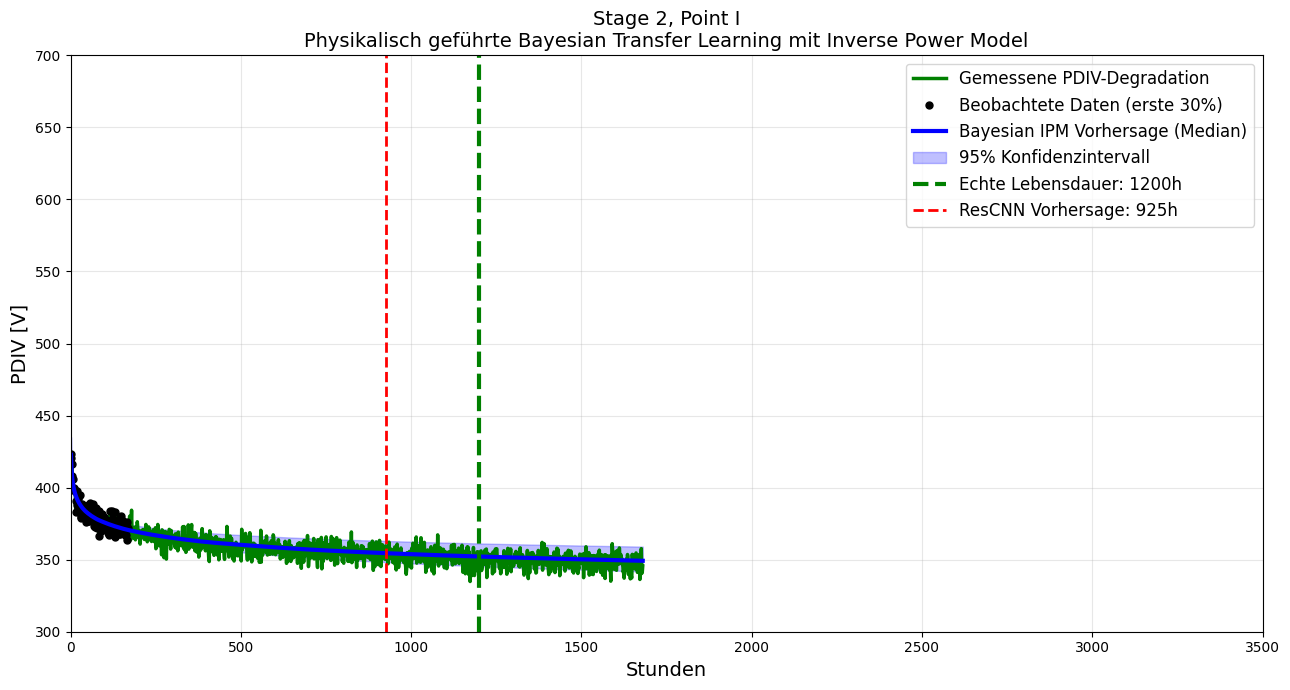

 R² stage 2: 0.9994
 MAE: 0.12 V
Stage 2 für Point II, echte Lebensdauer: 2610h


100%|██████████| 6000/6000 [00:06<00:00, 924.27it/s] 


Accepted 6400 samples, K = 588.5 ± 7.6, n = 0.04271 ± 0.04542


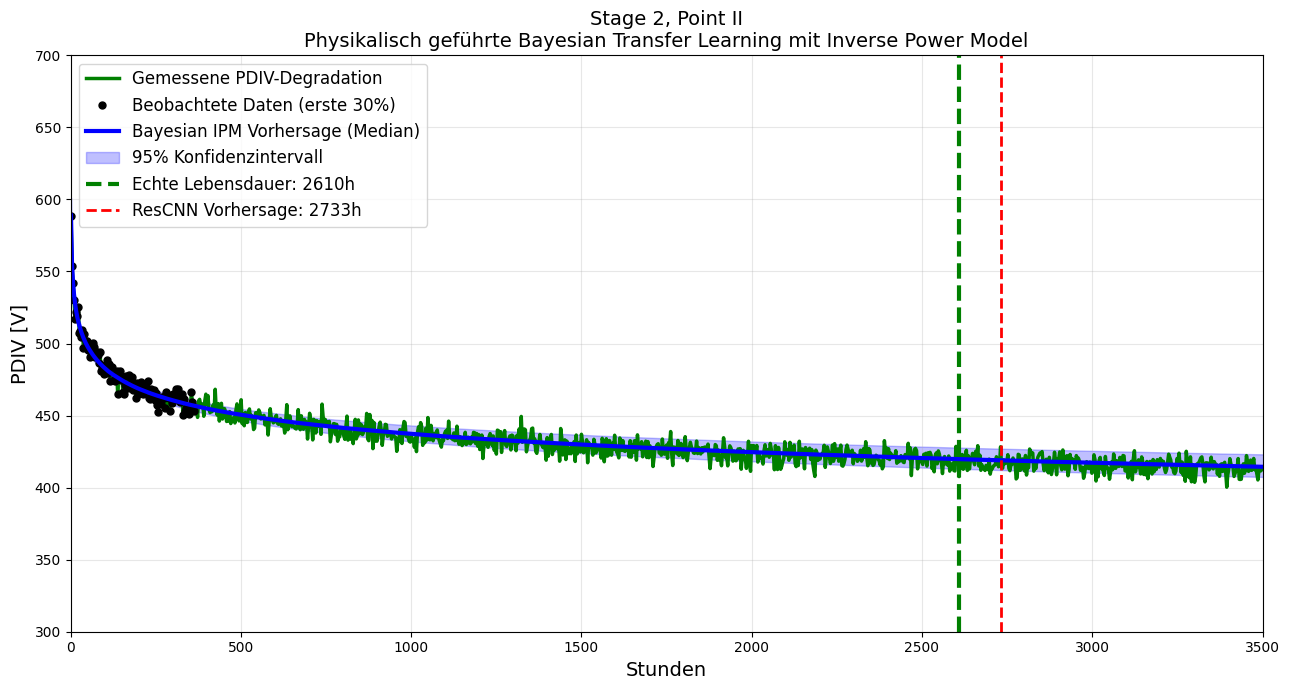

 R² stage 2: 0.9993
 MAE: 0.29 V
Stage 2 für Point III, echte Lebensdauer: 740h


100%|██████████| 6000/6000 [00:05<00:00, 1076.45it/s]


Accepted 6400 samples, K = 472.9 ± 5.8, n = 0.00836 ± 0.01248


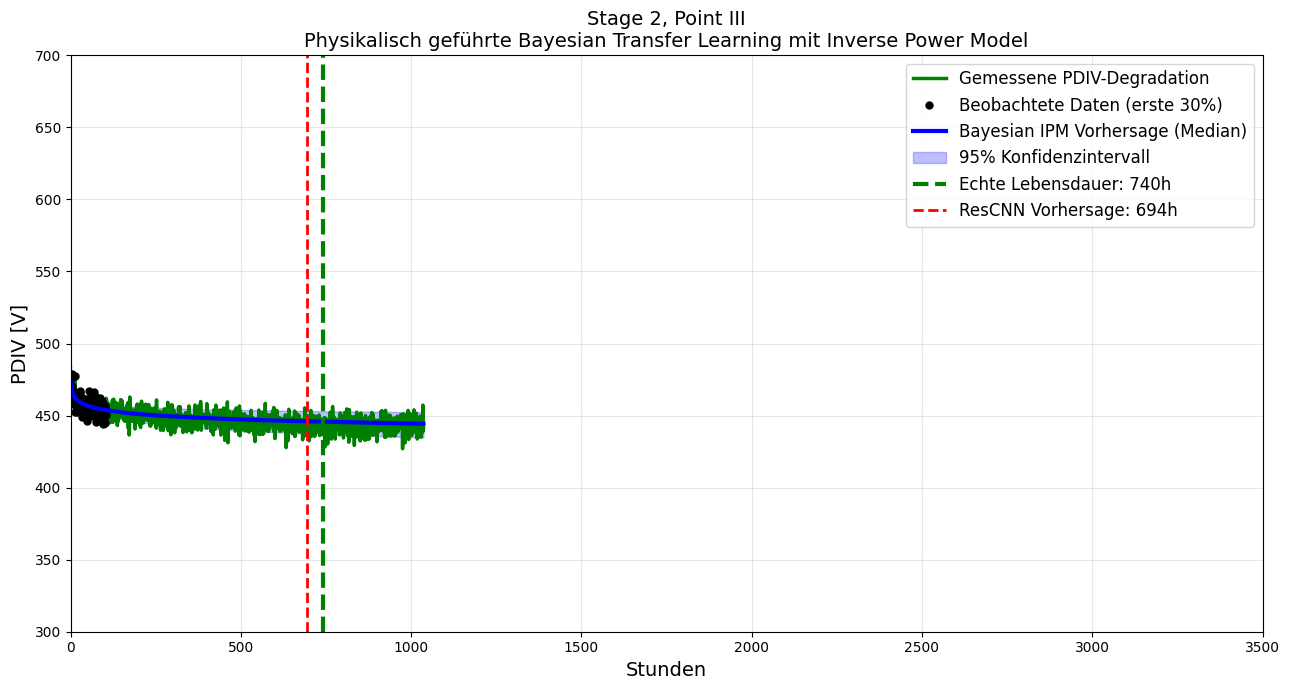

 R² stage 2: 0.7341
 MAE: 1.34 V
Stage 2 für Point IV, echte Lebensdauer: 741h


100%|██████████| 6000/6000 [00:05<00:00, 1015.92it/s]


Accepted 6400 samples, K = 546.0 ± 6.3, n = 0.04689 ± 0.05010


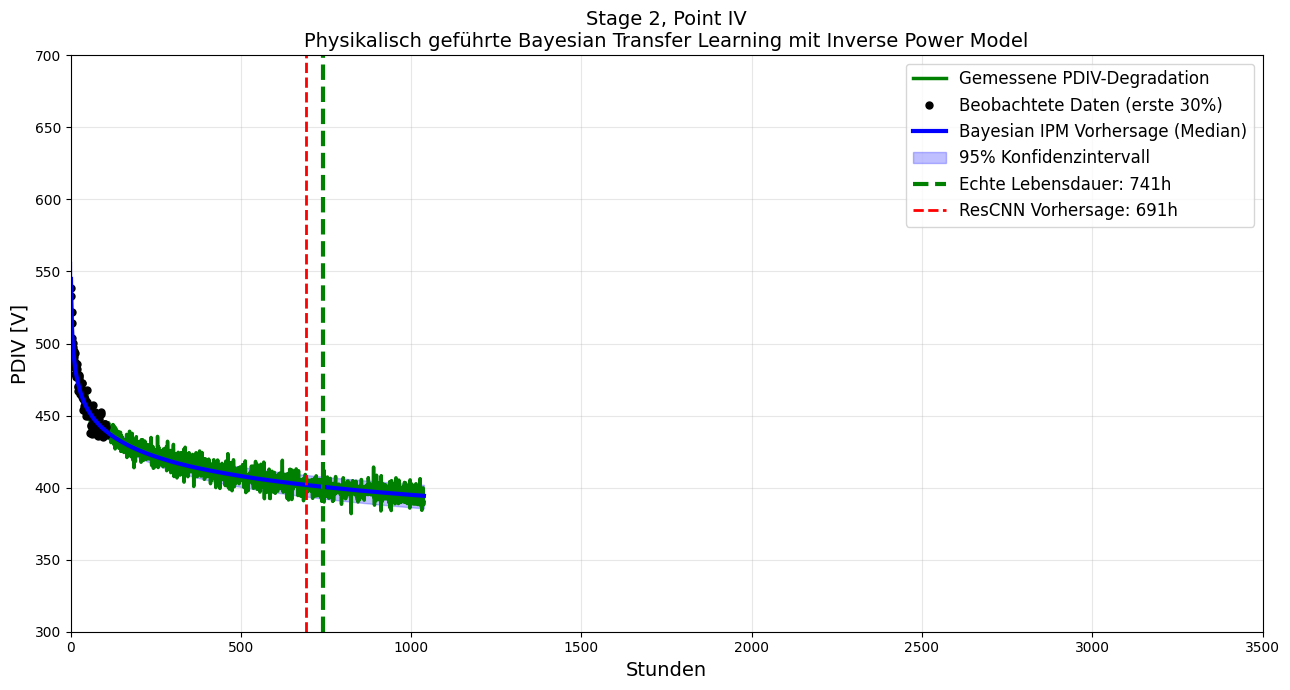

 R² stage 2: 0.9988
 MAE: 0.40 V
Stage 2 für Point V, echte Lebensdauer: 430h


100%|██████████| 6000/6000 [00:05<00:00, 1063.41it/s]


Accepted 6400 samples, K = 529.9 ± 5.6, n = 0.02861 ± 0.03207


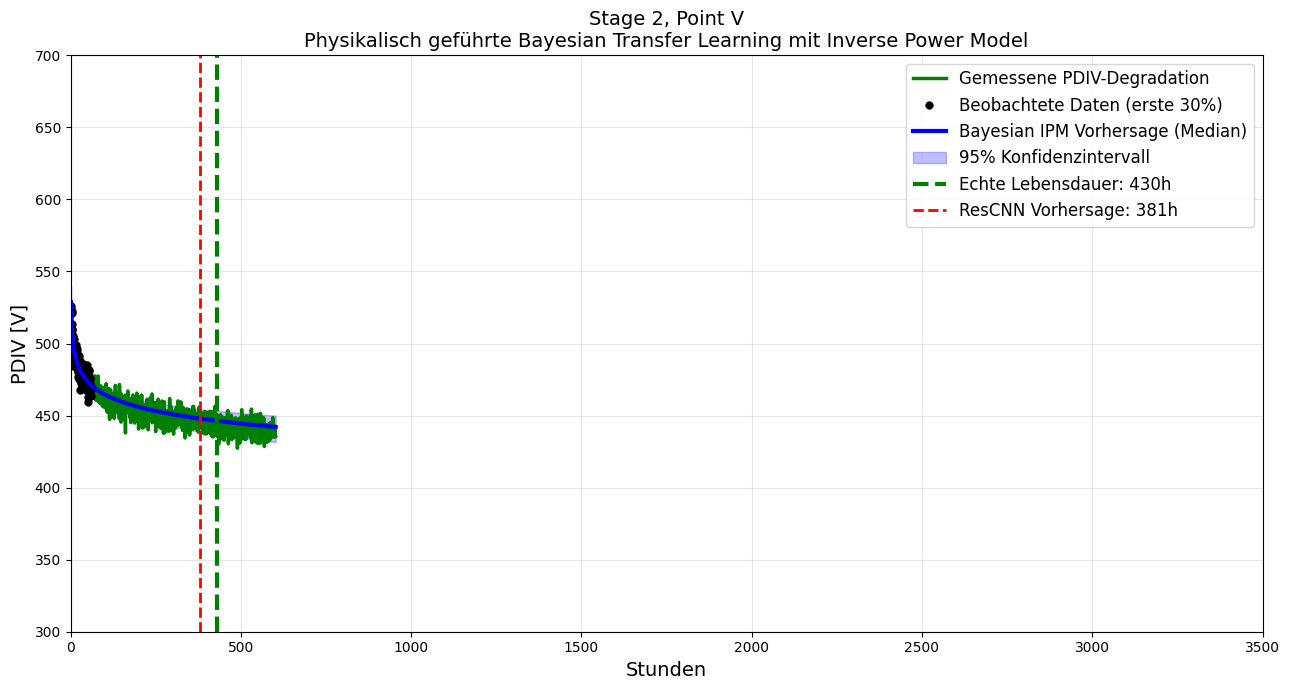

 R² stage 2: 0.9590
 MAE: 1.52 V
Stage 2 für Point VII, echte Lebensdauer: 657h


100%|██████████| 6000/6000 [00:05<00:00, 1043.03it/s]


Accepted 6400 samples, K = 543.9 ± 6.1, n = 0.04547 ± 0.04866


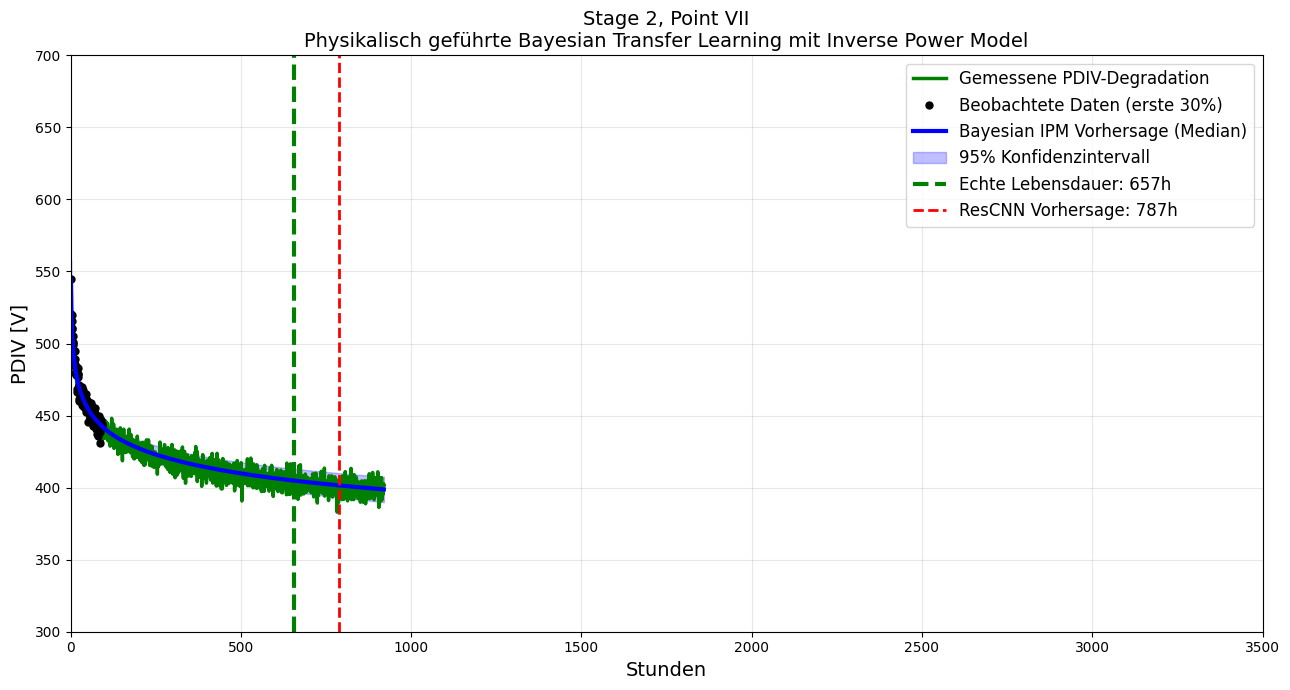

 R² stage 2: 0.9993
 MAE: 0.29 V
Stage 2 für Point VIII, echte Lebensdauer: 1922h


100%|██████████| 6000/6000 [00:05<00:00, 1064.05it/s]


Accepted 6400 samples, K = 558.9 ± 7.2, n = 0.04185 ± 0.04473


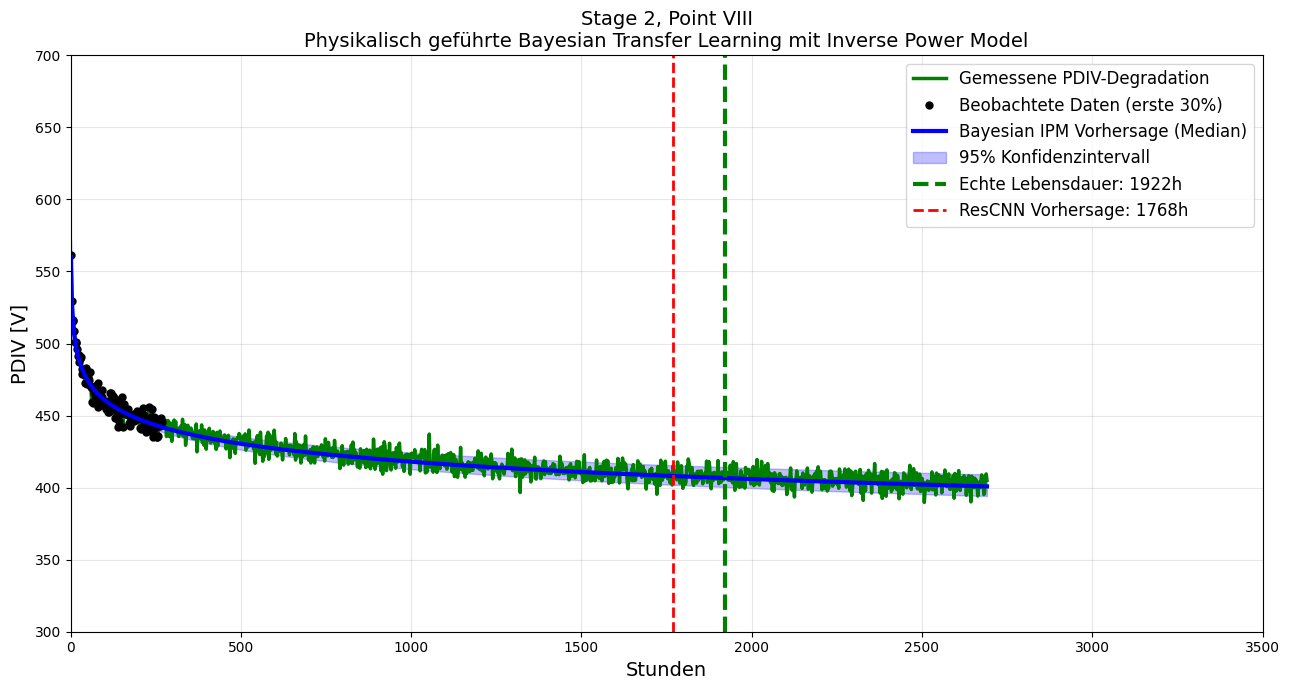

 R² stage 2: 0.9998
 MAE: 0.14 V
Stage 2 für Point X, echte Lebensdauer: 1224h


100%|██████████| 6000/6000 [00:05<00:00, 1016.84it/s]


Accepted 6400 samples, K = 547.7 ± 6.5, n = 0.03265 ± 0.03563


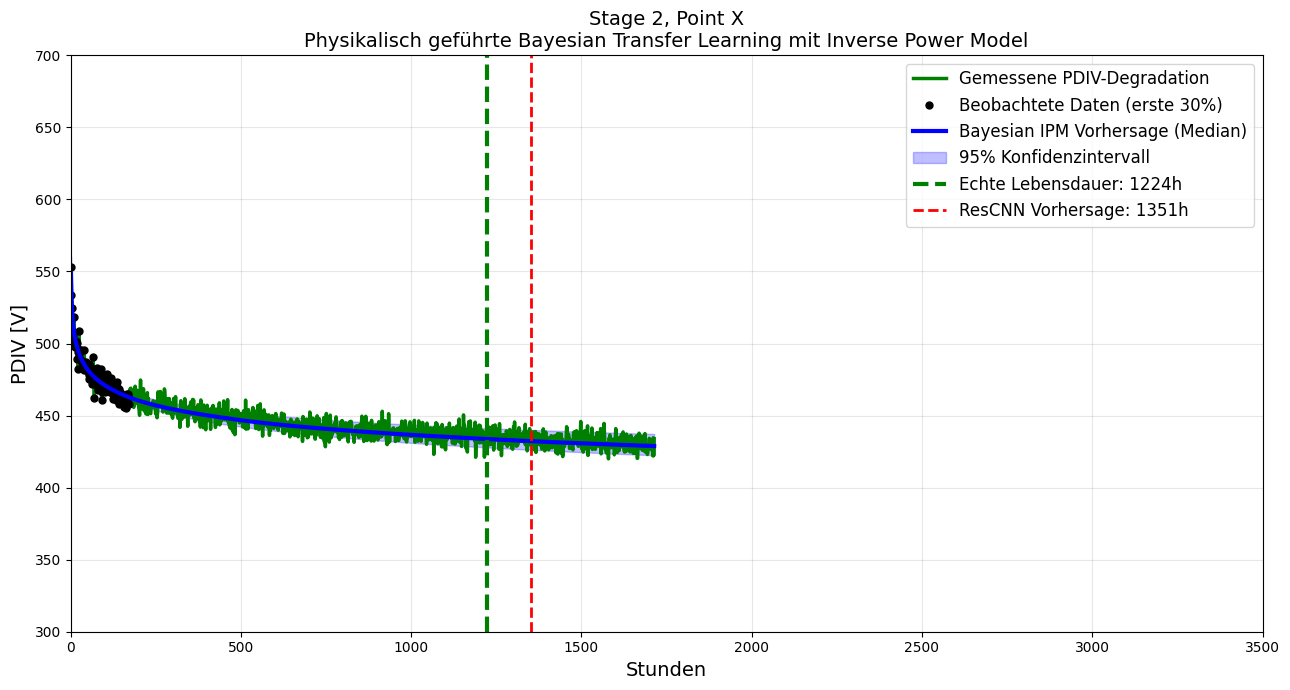

 R² stage 2: 0.9992
 MAE: 0.23 V


In [ ]:
#mean_curve_list = [] # Beispiel: Point II (bester Fit in der Dissertation)
for i in range(0,8):
    idx = i #hier ändern, um verschiedene Punkte zu testen 
    motor = test_data[idx]
    t_full = motor['t']
    pdiv_full = motor['PDIV']
    true_life = motor['lifetime']
    cnn_life = pred_life[idx]

    obs_n = int(0.1 * len(t_full))
    t_obs = t_full[:obs_n]
    pdiv_obs = pdiv_full[:obs_n]

    print(f"Stage 2 für Point {motor['point']}, echte Lebensdauer: {true_life}h")

    # MCMC
    ndim, nwalkers = 2, 64
    # Startwerte in der Nähe des wahren Werts (für schnelle Konvergenz)
    p0 = np.array([580, np.log(0.044)]) + 0.05 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t_obs, pdiv_obs))
    sampler.run_mcmc(p0, 6000, progress=True)
    samples = sampler.get_chain(discard=3000, thin=30, flat=True)

    print(f"Accepted {len(samples)} samples, "
      f"K = {np.mean(samples[:,0]):.1f} ± {np.std(samples[:,0]):.1f}, "
      f"n = {np.exp(np.mean(samples[:,1])):.5f} ± {np.exp(np.std(samples[:,1])) * np.exp(np.mean(samples[:,1])):.5f}")
      
    # Vorhersage
    n_samples = 150
    curves = []
    for i in np.random.randint(len(samples), size=n_samples):
        K, log_n = samples[i]
        curves.append(ipm_model(t_full, K, np.exp(log_n)))
    curves = np.array(curves)

    mean_curve = np.median(curves, axis=0)  # Median ist robuster als Mean
    lower = np.percentile(curves, 2.5, axis=0)
    upper = np.percentile(curves, 97.5, axis=0)

    #mean_curve_list.append(mean_curve)
    # Plot
    plt.figure(figsize=(13, 7))
    plt.plot(t_full, pdiv_full, 'g-', linewidth=2.5, label='Gemessene PDIV-Degradation')
    plt.plot(t_obs, pdiv_obs, 'ko', markersize=5, label='Beobachtete Daten (erste 30%)')
    plt.plot(t_full, mean_curve, 'b-', linewidth=3, label='Bayesian IPM Vorhersage (Median)')
    plt.fill_between(t_full, lower, upper, color='blue', alpha=0.25, label='95% Konfidenzintervall')
    plt.axvline(true_life, color='green', linestyle='--', linewidth=3, label=f'Echte Lebensdauer: {true_life}h')
    plt.axvline(cnn_life, color='red', linestyle='--', linewidth=2, label=f'ResCNN Vorhersage: {cnn_life:.0f}h')
    plt.xlabel('Stunden', fontsize=14)
    plt.ylabel('PDIV [V]', fontsize=14)
    plt.title(f'Stage 2, Point {motor['point']}\nPhysikalisch geführte Bayesian Transfer Learning mit Inverse Power Model', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3500)
    plt.ylim(300, 700)
    plt.tight_layout()
    plt.show()



    from scipy.optimize import curve_fit  
    # das IPM direkt auf die beobachteten Daten fitten
    popt, _ = curve_fit(ipm_model, t_obs, pdiv_obs, p0=[600, 0.04], bounds=([300, 0.001], [800, 0.1]))

    # Berechne den wahren Fit 
    true_fit_curve = ipm_model(t_full, *popt)

    #  vergleichen,  (aber nur die geglätteten Kurven)
    r2_s2 = r2_score(true_fit_curve[obs_n:], mean_curve[obs_n:])
    mae_s2 = mean_absolute_error(true_fit_curve[obs_n:], mean_curve[obs_n:])

    print(f" R² stage 2: {r2_s2:.4f}")
    print(f" MAE: {mae_s2:.2f} V")